In [7]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import random

In [8]:
returns = pd.read_csv("../data/processed/nvda_log_returns_2000_2026.csv", index_col=0)

X = returns.values.reshape(-1,1)

print("Observations:", len(X))

Observations: 6538


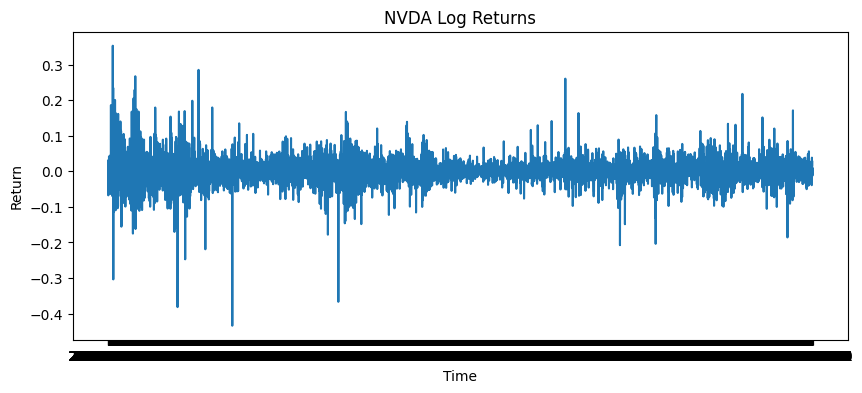

In [9]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("NVDA Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

The plot shows the daily log returns of NVDA over the sample period. Returns fluctuate around zero, which is expected since log returns remove long-term price trends and center the series near their mean.

Importantly, the magnitude of fluctuations varies over time, indicating periods of higher and lower volatility. This suggests the presence of time-varying volatility regimes, which motivates the use of a Hidden Markov Model (HMM) to capture the underlying distributions governing market behavior.

In [17]:
results = []
best_models = {}

for K in range(1,6):

    scores = []
    models = []

    print("\nTesting K =", K)

    for i in range(20):

        ran_state = random.randint(1,10000)

        model = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=2000,
            tol=1e-3,
            random_state=ran_state
        )

        model.fit(X)

        score = model.score(X)

        scores.append(score)
        models.append(model)


    best_idx = np.argmax(scores)
    best_model = models[best_idx]
    best_score = scores[best_idx]

    worst_score = min(scores)
    diff = best_score - worst_score

    print("Best score:", best_score)
    print("Worst score:", worst_score)
    print("Difference:", diff)

    best_models[K] = best_model

    results.append({
        "K":K,
        "best_logL":best_score,
        "worst_logL":worst_score,
        "diff":diff
    })


Testing K = 1
Best score: 12264.892841679377
Worst score: 12264.892841679377
Difference: 0.0

Testing K = 2
Best score: 13421.556251050375
Worst score: 13421.555214433556
Difference: 0.0010366168189648306

Testing K = 3


Model is not converging.  Current: 13625.196567104425 is not greater than 13625.199376087825. Delta is -0.0028089833995181834
Model is not converging.  Current: 13626.082575025928 is not greater than 13626.086670466868. Delta is -0.004095440939636319
Model is not converging.  Current: 13626.123217579923 is not greater than 13626.125068463856. Delta is -0.0018508839330024784
Model is not converging.  Current: 13627.52387107421 is not greater than 13627.526930040087. Delta is -0.003058965876334696
Model is not converging.  Current: 13626.104881376737 is not greater than 13626.110234300551. Delta is -0.005352923813916277
Model is not converging.  Current: 13626.060471593777 is not greater than 13626.066068063748. Delta is -0.0055964699713513255


Best score: 13627.514993403074
Worst score: 13625.185854935167
Difference: 2.329138467906887

Testing K = 4


Model is not converging.  Current: 13640.361197318527 is not greater than 13640.38186087597. Delta is -0.02066355744318571
Model is not converging.  Current: 13637.567927099148 is not greater than 13637.576025677956. Delta is -0.008098578808130696
Model is not converging.  Current: 13699.417459779375 is not greater than 13699.426737570811. Delta is -0.009277791436034022
Model is not converging.  Current: 13697.373620383065 is not greater than 13697.374200905146. Delta is -0.0005805220807815203
Model is not converging.  Current: 13686.435144063455 is not greater than 13686.438132639765. Delta is -0.0029885763105994556


Best score: 13699.403710019209
Worst score: 13637.546801990195
Difference: 61.85690802901445

Testing K = 5


Model is not converging.  Current: 13639.988640656331 is not greater than 13639.989229618259. Delta is -0.0005889619278605096


Best score: 13747.96125506288
Worst score: 13639.985521067256
Difference: 107.97573399562498


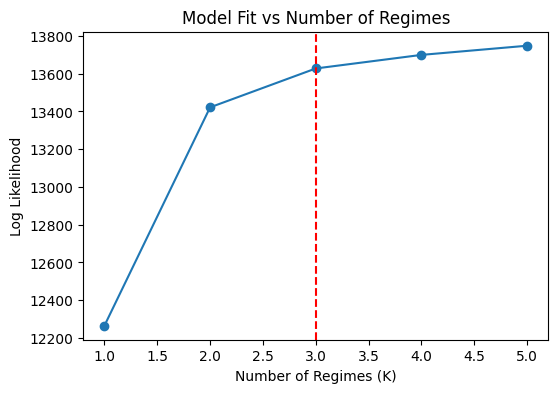

In [ ]:
Ks = [r["K"] for r in results]
scores = [r["best_logL"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, scores, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Log Likelihood")
plt.title("Model Fit vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

The plot shows the log-likelihood of the Hidden Markov Model as a function of the number of regimes K. As expected, the log-likelihood increases as additional regimes are introduced, since a more flexible model can better capture more structure in the data.

However, the marginal improvement in log-likelihood begins to diminish after K = 3. The sharp increase from K=1 to K=2 and the continued improvement at K=3 indicate that multiple volatility regimes are present in the return series. Beyond this point, the gains in model fit become relatively small. I believe this suggest that additional regimes primarily capture noise rather than meaningful structure.

The dashed vertical line highlights K=3 as the selected model (# of regimes). 

In [25]:
K = 3

model = best_models[K]

print("Final Model Score:", model.score(X))
print("Converged:", model.monitor_.converged)

Final Model Score: 13627.514993403074
Converged: True


Our chosen model will have 3 regimes, the next notebook will explore this model more in depth. Hopefully, we may also caputre different techniques to predict and how the prediction looks overall.